<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h2>Code</h2>

In [1]:
# now lets try to code grid and random search
# we will use the spiral data

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.utils import shuffle

In [3]:
def get_spiral():
    # first use poral co-ordinates
    # radius increases
    radii = np.linspace(1,10,100)
    thetas = np.empty((6,100))
    # theta also increase , so curvature increase
    for i in range(6): # we have 6 spirals
        theta_start = np.pi*i/3.0 # 0,60,120,180,240,300
        theta_end = theta_start + np.pi/2 # each spiral has a semi-circular sahpe
        thetas[i] = np.linspace(theta_start,theta_end,100)
     
    # next cartesian co-ordinates
    x1 = np.empty((6,100))
    x2 = np.empty((6,100))
    
    for i in range(6):
        x1[i] = radii * np.cos(thetas[i])
        x2[i] = radii * np.sin(thetas[i])
        
    X = np.empty((600,2))
    X[:,0] = x1.flatten()
    X[:,1] = x2.flatten()
    
    # add some noise
    X += np.random.randn(600,2)*0.5
    
    # targets
    Y = np.array([0]*100+[1]*100+[0]*100+[1]*100+[0]*100+[1]*100)
    return X,Y

In [40]:
X,Y = get_spiral() 
X,Y = shuffle(X,Y)

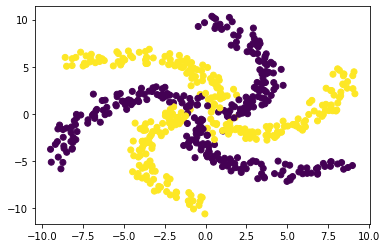

In [5]:
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()

In [6]:
# hyperparameters to test
hidden_layer_sizes = [[300],[100,100],[50,50,50]]
learning_rates = [1e-4,1e-3,1e-2]
l2_penalties = [0.,0.1,1.0]
momentums = [0.9,0.99,0.999]
best = {}

In [7]:
N = int(len(X)*0.7) # 70% train 30% test
Xtrain , Ytrain = X[:N],Y[:N]
Xtest , Ytest = X[N:],Y[N:]

In [8]:
best_score = 0
for lr in learning_rates:
    for l2 in l2_penalties:
        for size in hidden_layer_sizes:
            for mu in momentums:
                model = MLPClassifier(hidden_layer_sizes = size ,learning_rate_init=lr,alpha=l2,momentum=mu,max_iter=3000)
                model.fit(Xtrain,Ytrain)
                score = model.score(Xtest,Ytest)
                if score > best_score:
                    best_Score = score
                    best["lr"] = lr
                    best["l2"] = l2
                    best["validation score"] = score
                    best["momentum"] = mu
                    best["hidden layer size"] = size
print(best)

{'lr': 0.01, 'l2': 1.0, 'validation score': 0.9722222222222222, 'momentum': 0.999, 'hidden layer size': [50, 50, 50]}


In [9]:
# now lets try random search

In [72]:
max_iter = 30
hidden_layer_size = [20,20] 
log_lr = -1 # we search through log scale , learning rate 10**log_lr
log_l2 = -1 # same for l2 penalty
log_mu = -1 # same for momentum , momentum = 1-10**log_mu
best = {}

In [74]:
# we may be warned that MLP did not converge yet
# we will ignore this warning
# this may require several runs due to randomness
import warnings
warnings.filterwarnings('ignore')

In [77]:
best_score = 0
for _ in range(max_iter):
    model = MLPClassifier(hidden_layer_sizes = hidden_layer_size ,learning_rate_init=10**log_lr,alpha=10**log_l2,momentum=1-10**log_mu,max_iter=3000)
    model.fit(Xtrain,Ytrain)
    score = model.score(Xtest,Ytest)
    if score > best_score:
        best_Score = score
        best["log lr"] = log_lr
        best["log l2"] = log_l2
        best["validation score"] = score
        best["log momentum"] = log_mu
        best["hidden layer size"] = hidden_layer_size
    # now lets randomly select hyperparameters
    # imagine each hyperparameter as being a dimension and so the complete set of hyperparameters is a vector
    # now we are searching within a hypersphere around this vector
    # in other words we are going to go +/- a certain amount in each direction/parameter
    size = len(best["hidden layer size"]) + np.random.randint(-1,2) # -1,0 or 1
    size = max(1,size)
    units = best["hidden layer size"][0]
    units = units + np.random.randint(-1,2)*10
    units = max(10,units)
    hidden_layer_size = [units]*size
    log_lr = best["log lr"] + np.random.randint(-1,2)
    log_l2 = best["log l2"] + np.random.randint(-1,2)
    log_mu = best["log momentum"] + np.random.randint(-1,2)
    # max mu = 1 , max log_mu = 0
    log_mu = min(0,log_mu)
print(best)

{'log lr': -2, 'log l2': -4, 'validation score': 0.9777777777777777, 'log momentum': -2, 'hidden layer size': [20, 20, 20]}


<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math<h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Code</h1>

In [220]:
# this should be quick
# we will only change the forward function so that we multiply the matrix by a mask
# we will reuse the code on MNIST from 19 

In [221]:
import numpy as np

In [222]:
# these are the same from 17-feedforward
Nclass = 500

# 3 gaussian clouds
X1 = np.random.randn(Nclass,2) + np.array([0,-2])
X2 = np.random.randn(Nclass,2) + np.array([2,2])
X3 = np.random.randn(Nclass,2) + np.array([-2,2])

X = np.concatenate((X1,X2,X3))
# labels
Y = np.array([0]*Nclass+[1]*Nclass+[2]*Nclass)


In [223]:
def softmax(output):
    output = np.exp(output)
    output = output / output.sum(axis=1,keepdims=True)
    return output

def sigmoid(a):
    return 1/(1+np.exp(-a))

In [224]:
D = 2
M = 3
K = 3

p_keep = [0.8,0.5]

# we want targets to be NxK matrix , so we one hot encode the targets
# we need to one hot encode labels
def one_hot_encode(Y):
    N = len(Y)
    D = Y.max()+1
    encoded = np.zeros((N,D))
    for i in range(N):
        encoded[i,Y[i]] = 1
    return encoded

T = one_hot_encode(Y)

# next we define weights and bias terms
W = np.random.randn(D,M)
b = np.random.randn(M)

V = np.random.randn(M,K)
c = np.random.randn(K)

# here we change forward
def forward(X,W,b,act_fn,p_keep):
    mask = mask = np.random.binomial(n=1,p=p_keep,size=X.shape)
    out = (X*mask)@W+b
    act = act_fn(out)
    return act

    
epochs = 1000

lr = 0.0001 

for i in range(epochs):
    # feedforward
    Z = forward(X,W,b,sigmoid,p_keep[0])
    y = forward(Z,V,c,softmax,p_keep[1])
    
    #calculate gradients
    delta = T-y
    grad_V = Z.T@(delta)
    grad_c = delta.sum(axis=0)
    
    Z_prime = Z*(1-Z)
    grad_b = ((delta@V.T)*Z_prime)
    grad_W = X.T@grad_b
    grad_b = grad_b.sum(axis=0)
        
    # now we perform gradient ascent
    b += lr*grad_b
    c += lr*grad_c
    W += lr*grad_W
    V += lr*grad_V

In [225]:
# now lets get predictions and caluclate accuracy
Z = forward(X*p_keep[0],W,b,sigmoid,1)
y = forward(Z*p_keep[1],V,c,softmax,1)
preds = np.argmax(y,axis=1)
print("accuracy: ",np.mean(preds==Y))

accuracy:  0.9466666666666667


<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math</h1>

omitted

<h1>Math<h1>

omitted

<h1>code<h1>

In [2]:
# in the next part we will introduce tensorflow and pytorch
# instead of calculating gradients ourselves , these libraries do automatic differentiation
# also have very useful built in functions
# so we leave batch normalisation to the next part